## AML Project 2: SPAM Dataset

In [22]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectFromModel
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from boruta import BorutaPy
import xgboost as xgb
from sklearn.metrics import accuracy_score

### PART 1: DATASET

In [23]:
sms_train = pd.read_csv('sms_train.csv')
sms_test = pd.read_csv('sms_test.csv')
sms_validation = pd.read_csv('sms.tsv', sep='\t', names=['label', 'message'])

In [25]:
# data preprocessing
sms_train['message'] = sms_train['message'].str.lower()
sms_validation['label'] = sms_validation['label'].map({'ham': 0, 'spam': 1})
sms_validation['message'] = sms_validation['message'].str.lower()
sms_test['message'] = sms_test['message'].str.lower()

vectorizer = CountVectorizer()
X_train = vectorizer.fit_transform(sms_train['message'])
y_train = sms_train['label']

X_validation = vectorizer.transform(sms_validation['message'])
y_validation = sms_validation['label']

X_test = vectorizer.transform(sms_test['message'])

### PART 2: FEATURE SELECTION METHODS & TRAINING

### PART 2.1: ORIGINAL FEATURES

In [28]:
accuracies = []
num_selected_features = []

xgb_model = xgb.XGBClassifier().fit(X_train.toarray(), y_train)
pred_xgb_original = xgb_model.predict(X_validation.toarray())
accuracies.append(accuracy_score(y_validation, pred_xgb_original))
num_selected_features.append(X_train.shape[1])

In [29]:
print('Accuracies: ', accuracies)
print('Number of features (original): ', num_selected_features)

Accuracies:  [0.992462311557789]
Number of features (original):  [7913]


### PART 2.2: BORUTA METHOD

In [31]:
model = RandomForestClassifier()

accu = []

for iteration in range(10,21,1):
    selector = BorutaPy(model, n_estimators='auto',verbose=0, max_iter=iteration).fit(X_train.toarray(), y_train)

    # getting selected features
    X_filtered = selector.transform(X_train.toarray())
    X_valid_filtered = selector.transform(X_validation.toarray())

    xgb_model = xgb.XGBClassifier().fit(X_filtered, y_train)

    pred_xgb_boruta = xgb_model.predict(X_valid_filtered)
    accu.append( accuracy_score(y_validation, pred_xgb_boruta) )

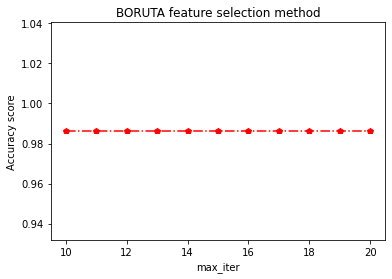

In [33]:
import matplotlib.pyplot as plt

plt.plot(np.arange(10,21,1), accu, 'r-.p')
plt.xlabel("max_iter")
plt.ylabel("Accuracy score")
plt.title("BORUTA feature selection method")
plt.show()

In [34]:
iter_opt = np.arange(10,21,1)[ accu.index( max(accu) ) ]
print("The optimal max_iter is {}.".format(iter_opt))

The optimal max_iter is 10.


In [35]:
# use identified optimal max_iter val
selector = BorutaPy(model, n_estimators='auto',verbose=0, max_iter=iter_opt).fit(X_train.toarray(), y_train)

X_filtered = selector.transform(X_train.toarray())
X_valid_filtered = selector.transform(X_validation.toarray())

xgb_model = xgb.XGBClassifier().fit(X_filtered, y_train)

# predict the classification of test set and compute the accuracy of prediction
pred_xgb_boruta = xgb_model.predict(X_valid_filtered)

In [36]:
print( 'The smallest subset of {} features are selected.'.format( sum( selector.support_ )) ) 

The smallest subset of 42 features are selected.


In [52]:
# all results for accuracy and selected number of features will be further saved here:
acc_list = []
features_list = []
acc_list.append( accuracy_score( y_validation ,pred_xgb_boruta ) )
features_list.append( sum( selector.support_ ) )

### PART 2.2: RFE SELECTOR

In [46]:
from sklearn.feature_selection import RFE
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier

accu_rfe = []
for num_feature in range(10,101,10):
    svm = LinearSVC(dual=False)
    rfe = RFE(svm,n_features_to_select= num_feature)
    rfe.fit( X_train.toarray(), y_train )
    X_train_filtered = X_train.toarray()[:, np.r_[ np.where( rfe.support_ )   ]]
    X_valid_filtered = X_validation.toarray()[:, np.r_[ np.where( rfe.support_ )   ]]
    xgb_model = xgb.XGBClassifier().fit(X_train_filtered, y_train)
    pred_xgb_filtered = xgb_model.predict(X_valid_filtered)
    accu_rfe.append( accuracy_score(y_validation, pred_xgb_filtered) )
num_feature_opt = np.arange(10,101,10)[ accu_rfe.index( max(accu_rfe) ) ]
print("The optimal n_features_to_select is {}".format(num_feature_opt))

The optimal n_features_to_select is 50


In [47]:
svm = LinearSVC(dual=False)
rfe = RFE(svm,n_features_to_select= 50)
rfe.fit( X_train.toarray(), y_train )

X_train_filtered = X_train.toarray()[:, np.r_[ np.where( rfe.support_ )   ]]
X_valid_filtered = X_validation.toarray()[:, np.r_[ np.where( rfe.support_ )   ]]

In [50]:
xgb_model = xgb.XGBClassifier().fit(X_train_filtered, y_train)

In [51]:
pred_xgb_rfe = xgb_model.predict(X_valid_filtered)
accuracy_score(y_validation, pred_xgb_rfe)

0.967516152189519

In [53]:
# results saved 
acc_list.append( accuracy_score( y_validation ,pred_xgb_rfe ) )
features_list.append( 50 )

### PART 2.4: LASSO 

In [74]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.01, max_iter=1000).fit(X_train.toarray(), y_train)
selected_features = np.where(lasso.coef_ != 0)[0]

X_train_filtered = X_train.toarray()[:, selected_features]
X_valid_filtered = X_validation.toarray()[:, selected_features]

In [75]:
print('Lasso: Number of selected features:', X_train_filtered.shape[1])

Lasso: Number of selected features: 17


In [76]:
xgb_model = xgb.XGBClassifier().fit(X_train_filtered, y_train)
pred_xgb_lasso = xgb_model.predict(X_valid_filtered)

In [77]:
acc_list.append( accuracy_score( y_validation ,pred_xgb_lasso ) )
features_list.append( X_train_filtered.shape[1] )

### PART 2.5: CHI-SQUARE 

In [79]:
from sklearn.feature_selection import SelectKBest, chi2

acc_chi = []
for i in range(1,21,2):
    chi2_selector = SelectKBest(chi2, k=i)
    X_train_filtered = chi2_selector.fit_transform(X_train.toarray(), y_train)
    X_valid_filtered = X_validation.toarray()[:, chi2_selector.get_support() ]
    xgb_model = xgb.XGBClassifier()
    xgb_model.fit(X_train_filtered, y_train)
    pred_xgb_chis = xgb_model.predict(X_valid_filtered)
    acc_chi.append( accuracy_score(y_validation, pred_xgb_chis) )

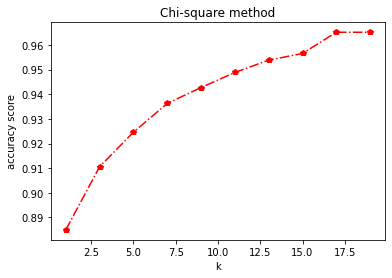

In [80]:
import matplotlib.pyplot as plt
plt.plot(np.arange(1,21,2), acc_chi, 'r-.p')
plt.xlabel("k")
plt.ylabel("accuracy score")
plt.title("Chi-square method")
plt.show()

In [81]:
k_chi_opt = np.arange(1,21,2)[ acc_chi.index( max(acc_chi) ) ]
print("The optimal k is {}.".format(k_chi_opt))

The optimal k is 17.


In [82]:
chi2_selector = SelectKBest(chi2, k=k_chi_opt)
X_train_filtered = chi2_selector.fit_transform(X_train.toarray(), y_train)
X_valid_filtered = X_validation.toarray()[ :, chi2_selector.get_support() ]
xgb_model = xgb.XGBClassifier().fit(X_train_filtered, y_train)
pred_xgb_chis = xgb_model.predict(X_valid_filtered)

In [83]:
acc_list.append( accuracy_score(y_validation, pred_xgb_chis))
features_list.append(k_chi_opt)

### PART 3: BALANCED ACCURACY

In [128]:
# initial accuracy scores calculated by accuracy_score func
print(acc_list)
# number of features: original, boruta, rfe, lasso, chi-square
print(features_list)

[0.992462311557789, 0.9861809045226131, 0.967516152189519, 0.9752333094041636, 0.9651830581478823]
[7913, 42, 50, 17, 17]


In [150]:
# original

pred_binary = pred_xgb_original
actual_binary = y_validation

TP = sum([1 for pred, actual in zip(pred_binary, actual_binary) if pred == 1 and actual == 1])
TN = sum([1 for pred, actual in zip(pred_binary, actual_binary) if pred == 0 and actual == 0])
P = sum(actual_binary)
N = len(actual_binary) - P

if P == 0 or N == 0:
    BA = 0  
else:
    BA = (TP/P + TN/N) / 2

m = features_list[0] 

orig = BA - 0.01 * max(0, (1/100 * m - 1))

print("Balanced Accuracy (BA):", BA)
print("Number of selected features (m):", m)
print("Final Score:", orig)

Balanced Accuracy (BA): 0.9741504186001346
Number of selected features (m): 7913
Final Score: 0.19285041860013463


In [138]:
# boruta

pred_binary = pred_xgb_boruta
actual_binary = y_validation

TP = sum([1 for pred, actual in zip(pred_binary, actual_binary) if pred == 1 and actual == 1])
TN = sum([1 for pred, actual in zip(pred_binary, actual_binary) if pred == 0 and actual == 0])
P = sum(actual_binary)
N = len(actual_binary) - P

if P == 0 or N == 0:
    BA = 0  
else:
    BA = (TP/P + TN/N) / 2

m = features_list[1] 

score = BA - 0.01 * max(0, (1/100 * m - 1))

print("Balanced Accuracy (BA):", BA)
print("Number of selected features (m):", m)
print("Final Score:", score)

Balanced Accuracy (BA): 0.9569462651989651
Number of selected features (m): 42
Final Score: 0.9569462651989651


In [139]:
# rfe

pred_binary = pred_xgb_rfe
actual_binary = y_validation

TP = sum([1 for pred, actual in zip(pred_binary, actual_binary) if pred == 1 and actual == 1])
TN = sum([1 for pred, actual in zip(pred_binary, actual_binary) if pred == 0 and actual == 0])
P = sum(actual_binary)
N = len(actual_binary) - P

if P == 0 or N == 0:
    BA = 0  
else:
    BA = (TP/P + TN/N) / 2

m = features_list[2] 

score_rfe = BA - 0.01 * max(0, (1/100 * m - 1))

print("Balanced Accuracy (BA):", BA)
print("Number of selected features (m):", m)
print("Final Score:", score_rfe)

Balanced Accuracy (BA): 0.8873344847438112
Number of selected features (m): 50
Final Score: 0.8873344847438112


In [144]:
# lasso

pred_binary = pred_xgb_lasso
actual_binary = y_validation

TP = sum([1 for pred, actual in zip(pred_binary, actual_binary) if pred == 1 and actual == 1])
TN = sum([1 for pred, actual in zip(pred_binary, actual_binary) if pred == 0 and actual == 0])
P = sum(actual_binary)
N = len(actual_binary) - P

if P == 0 or N == 0:
    BA = 0  
else:
    BA = (TP/P + TN/N) / 2

m = features_list[3] 

score_lasso = BA - 0.01 * max(0, (1/100 * m - 1))

print("Balanced Accuracy (BA):", BA)
print("Number of selected features (m):", m)
print("Final Score:", score_lasso)

Balanced Accuracy (BA): 0.9212077324843415
Number of selected features (m): 17
Final Score: 0.9212077324843415


In [145]:
# chi-square

pred_binary = pred_xgb_chis
actual_binary = y_validation

TP = sum([1 for pred, actual in zip(pred_binary, actual_binary) if pred == 1 and actual == 1])
TN = sum([1 for pred, actual in zip(pred_binary, actual_binary) if pred == 0 and actual == 0])
P = sum(actual_binary)
N = len(actual_binary) - P

if P == 0 or N == 0:
    BA = 0  
else:
    BA = (TP/P + TN/N) / 2

m = features_list[4] 

score_chi = BA - 0.01 * max(0, (1/100 * m - 1))

print("Balanced Accuracy (BA):", BA)
print("Number of selected features (m):", m)
print("Final Score:", score_chi)

Balanced Accuracy (BA): 0.8865530515845766
Number of selected features (m): 17
Final Score: 0.8865530515845766


### PART 4: RESULTS

In [96]:
# i forgot to include the results by the original features so i inserted them here 
acc_list.insert(0, 0.992462311557789)
print(acc_list)
features_list.insert(0, 7913)
print(features_list)

[0.992462311557789, 0.992462311557789, 0.967516152189519, 0.9752333094041636, 0.9651830581478823]
[7913, 7913, 42, 50, 17, 17]


In [146]:
print('Accuracy scores obtained from accuracy_score: ', acc_list)

Accuracy scores obtained from accuracy_score:  [0.992462311557789, 0.9861809045226131, 0.967516152189519, 0.9752333094041636, 0.9651830581478823]


In [147]:
print('Number of features: ', features_list)

Number of features:  [7913, 42, 50, 17, 17]


In [155]:
print('Balanced accuracy results: ', orig, score, score_rfe, score_lasso, score_chi)

Balanced accuracy results:  0.19285041860013463 0.9569462651989651 0.8865530515845766 0.9212077324843415 0.8865530515845766


In [156]:
ba_list = [orig, score, score_rfe, score_lasso, score_chi]

In [105]:
import plotly.graph_objects as go
animals=['original','boruta','RFE','Lasso','chi square']

fig = go.Figure(
    data=[
        go.Bar(name='xgboost acc', x=animals, y=acc_list, yaxis='y', offsetgroup=1),
        go.Bar(name='# of features', x=animals, y=features_list, yaxis='y2', offsetgroup=2)
    ],
    layout={
        'yaxis': {'title': 'accuracy'},
        'yaxis2': {'title': 'number of features', 'overlaying': 'y', 'side': 'right'}
    }
)


fig.update_layout(barmode='group',
                 title={
        'text': "The number of selected features by 4 selectors and the accuracy_score of xgboost classifier (sklearn)",
        'y':0.9,
        'x':0.5,
        'xanchor': 'center',
        'yanchor': 'top'}
                 )
fig.show()

In [107]:
# next is getting only results for used feature selection methods without original one
acc_list2 = acc_list[1:]
features_list2 = features_list[1:]

In [108]:
import plotly.graph_objects as go
animals=['boruta','RFE','Lasso','chi square']

fig = go.Figure(
    data=[
        go.Bar(name='xgboost acc', x=animals, y=acc_list2, yaxis='y', offsetgroup=1),
        go.Bar(name='# of features', x=animals, y=features_list2, yaxis='y2', offsetgroup=2)
    ],
    layout={
        'yaxis': {'title': 'accuracy'},
        'yaxis2': {'title': 'number of features', 'overlaying': 'y', 'side': 'right'}
    }
)


fig.update_layout(barmode='group',
                 title={
        'text': "The number of selected features by 4 selectors and the accuracy of xgboost classifier trained by them",
        'y':0.9,
        'x':0.5,
        'xanchor': 'center',
        'yanchor': 'top'}
                 )
fig.show()

In [162]:
import plotly.graph_objects as go
animals=['original','boruta','RFE','Lasso','chi square']

fig = go.Figure(
    data=[
        go.Bar(name='xgboost acc', x=animals, y=ba_list, yaxis='y', offsetgroup=1),
        go.Bar(name='# of features', x=animals, y=features_list, yaxis='y2', offsetgroup=2)
    ],
    layout={
        'yaxis': {'title': 'accuracy'},
        'yaxis2': {'title': 'number of features', 'overlaying': 'y', 'side': 'right'}
    }
)


fig.update_layout(barmode='group',
                 title={
        'text': "The number of selected features by 4 selectors and the accuracy of xgboost classifier by Score(BA,m)",
        'y':0.9,
        'x':0.5,
        'xanchor': 'center',
        'yanchor': 'top'}
                 )
fig.show()

In [163]:
import plotly.graph_objects as go
animals=['boruta','RFE','Lasso','chi square']

fig = go.Figure(
    data=[
        go.Bar(name='xgboost acc', x=animals, y=ba_list[1:], yaxis='y', offsetgroup=1),
        go.Bar(name='# of features', x=animals, y=features_list[1:], yaxis='y2', offsetgroup=2)
    ],
    layout={
        'yaxis': {'title': 'accuracy'},
        'yaxis2': {'title': 'number of features', 'overlaying': 'y', 'side': 'right'}
    }
)


fig.update_layout(barmode='group',
                 title={
        'text': "The number of selected features by 4 selectors and the accuracy of xgboost classifier by Score(BA,m)",
        'y':0.9,
        'x':0.5,
        'xanchor': 'center',
        'yanchor': 'top'}
                 )
fig.show()

From the results above, we conclude that the two best feature selection methods are Lasso and Chi-square as both of them select the smallest number of features. However, by looking at the accuracy score, Lasso has better performance. So next we procceed with Lasso method and find out the most applicable classification algorithm.

In [109]:
lasso = Lasso(alpha=0.01, max_iter=1000).fit(X_train.toarray(), y_train)
selected_features = np.where(lasso.coef_ != 0)[0]

X_train_filtered = X_train.toarray()[:, selected_features]
X_valid_filtered = X_validation.toarray()[:, selected_features]

C:\Users\Nazira\anaconda3\lib\site-packages\sklearn\discriminant_analysis.py:878: UserWarning:

Variables are collinear



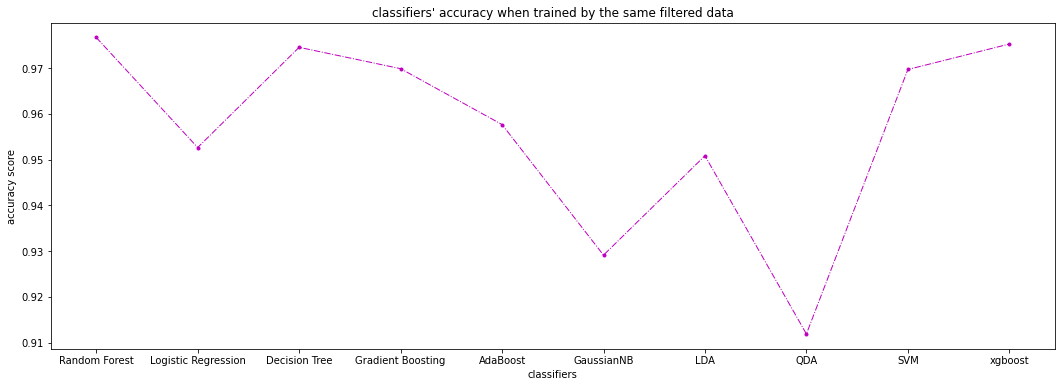

In [110]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn import tree
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.svm import SVC

classification_algorithms = (
    ('Random Forest', RandomForestClassifier(random_state=11) ),
    ('Logistic Regression', LogisticRegression(penalty='l2') ),
    ('Decision Tree', tree.DecisionTreeClassifier() ),
    ('Gradient Boosting', GradientBoostingClassifier() ),
    ('AdaBoost', AdaBoostClassifier() ),
    ('GaussianNB', GaussianNB() ),
    ('LDA', LinearDiscriminantAnalysis() ),
    ('QDA', QuadraticDiscriminantAnalysis() ),
    ('SVM', SVC(kernel='rbf', probability=True) ),
    ('xgboost', xgb.XGBClassifier() ),
)

names = []
accs = []
for name, algorithm in classification_algorithms:
    algorithm.fit(X_train_filtered, y_train)
    pred_filtered = algorithm.predict(X_valid_filtered)
    acc = accuracy_score(y_validation, pred_filtered)
    names.append(name)
    accs.append(acc)
    
plt.figure(figsize=(18, 6))
plt.plot(names, accs, 'm.-.', linewidth=1)
plt.xlabel('classifiers')
plt.ylabel('accuracy score')
plt.title('classifiers\' accuracy when trained by the same filtered data' )
plt.show()

C:\Users\Nazira\anaconda3\lib\site-packages\sklearn\discriminant_analysis.py:878: UserWarning:

Variables are collinear



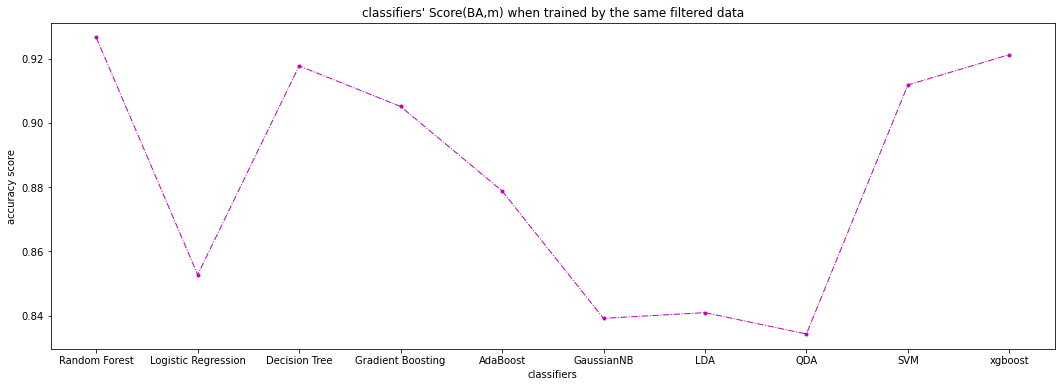

In [159]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn import tree
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.svm import SVC

classification_algorithms = (
    ('Random Forest', RandomForestClassifier(random_state=11) ),
    ('Logistic Regression', LogisticRegression(penalty='l2') ),
    ('Decision Tree', tree.DecisionTreeClassifier() ),
    ('Gradient Boosting', GradientBoostingClassifier() ),
    ('AdaBoost', AdaBoostClassifier() ),
    ('GaussianNB', GaussianNB() ),
    ('LDA', LinearDiscriminantAnalysis() ),
    ('QDA', QuadraticDiscriminantAnalysis() ),
    ('SVM', SVC(kernel='rbf', probability=True) ),
    ('xgboost', xgb.XGBClassifier() ),
)

names = []
scores = []
for name, algorithm in classification_algorithms:
    algorithm.fit(X_train_filtered, y_train)
    pred_filtered = algorithm.predict(X_valid_filtered)
    
    pred_binary = pred_filtered
    actual_binary = y_validation

    TP = sum([1 for pred, actual in zip(pred_binary, actual_binary) if pred == 1 and actual == 1])
    TN = sum([1 for pred, actual in zip(pred_binary, actual_binary) if pred == 0 and actual == 0])
    P = sum(actual_binary)
    N = len(actual_binary) - P

    if P == 0 or N == 0:
        BA = 0  
    else:
        BA = (TP/P + TN/N) / 2

    m = features_list[4] 

    model_score = BA - 0.01 * max(0, (1/100 * m - 1))

    names.append(name)
    scores.append(model_score)
    
plt.figure(figsize=(18, 6))
plt.plot(names, scores, 'm.-.', linewidth=1)
plt.xlabel('classifiers')
plt.ylabel('accuracy score')
plt.title('classifiers\' Score(BA,m) when trained by the same filtered data' )
plt.show()

In [161]:
df = pd.DataFrame({'Classification Model': names, 'Accuracy': accs, 'Score(BA,m)':scores})
df

,Classification Model,Accuracy,"Score(BA,m)"
0,Random Forest,0.976669,0.926562
1,Logistic Regression,0.952620,0.852710
2,Decision Tree,0.974515,0.917710
3,Gradient Boosting,0.969849,0.905087
4,AdaBoost,0.957645,0.878806
5,GaussianNB,0.929110,0.839135
6,LDA,0.950826,0.840926
7,QDA,0.911881,0.834279
8,SVM,0.969670,0.911772
9,xgboost,0.975233,0.921208


Random Forest performs better when compared to other 9 models presented above.

In [113]:
lasso = Lasso(alpha=0.01, max_iter=1000).fit(X_train.toarray(), y_train)
selected_features = np.where(lasso.coef_ != 0)[0]

X_train_filtered = X_train.toarray()[:, selected_features]
X_test_filtered = X_test.toarray()[:, selected_features]

In [117]:
selected_features

array([1632, 1851, 3047, 3082, 4500, 4635, 4758, 4945, 5077, 6642, 6944,
       7094, 7257, 7357, 7811, 7872, 7877], dtype=int64)

In [119]:
np.savetxt('NAZTUK_spam_features.txt', selected_features, fmt='%d')

In [120]:
clf = RandomForestClassifier(random_state=11).fit(X_train_filtered, y_train)
clf.predict(X_test_filtered)

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,

In [121]:
post_pre = clf.predict_proba(X_test_filtered)[:,1]

In [124]:
np.savetxt('NAZTUK_spam_predictions.txt', post_pre, fmt='%d')